In [1]:
import torch

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 2050


In [2]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(PROJECT_ROOT)

C:\Users\jebij\OneDrive\Desktop\ARAHFL-Medical-Federated-Learning


In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from src.models import MediumCNN
from src.client import Client
from src.server import Server
from src.reliability import ReliabilityTracker

from src.utils import (
    load_pathmnist,
    partition_dirichlet,
    inject_corruption
)

print("Imports Loaded")

Imports Loaded


In [4]:
train_dataset, test_dataset = load_pathmnist()

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 89996
Test: 7180


In [5]:
client_datasets = partition_dirichlet(
    train_dataset,
    num_clients=5,
    alpha=0.5
)

print("Clients:", len(client_datasets))

Clients: 5


In [6]:
client_loaders = []

for dataset in client_datasets:

    loader = DataLoader(
        dataset,
        batch_size=128,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    client_loaders.append(loader)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Loaders Ready")

Loaders Ready


In [7]:
def evaluate(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    device = (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    model.to(device)

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            labels = labels.squeeze().long().to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    return correct / total

In [8]:
def fedavg(local_weights):

    avg_weights = {}

    for key in local_weights[0]:

        avg_weights[key] = sum(
            w[key]
            for w in local_weights
        ) / len(local_weights)

    return avg_weights

In [9]:
global_model = MediumCNN(
    num_classes=9
)

print("Baseline Model Ready")

Baseline Model Ready


In [10]:
baseline_clients = []

for loader in client_loaders:

    model = MediumCNN(
        num_classes=9
    )

    model.load_state_dict(
        global_model.state_dict()
    )

    client = Client(
        model=model,
        train_loader=loader
    )

    baseline_clients.append(
        client
    )

print(
    "Baseline clients created:",
    len(baseline_clients)
)

Baseline clients created: 5


In [11]:
baseline_accuracy = []

ROUNDS = 25

for rnd in range(ROUNDS):

    print(
        f"\n===== BASELINE ROUND {rnd+1} ====="
    )

    local_weights = []

    for client in baseline_clients:

        loss, reliability = client.train(
            epochs=1
        )

        local_weights.append(
            client.get_weights()
        )

    global_weights = fedavg(
        local_weights
    )

    global_model.load_state_dict(
        global_weights
    )

    for client in baseline_clients:

        client.set_weights(
            global_weights
        )

    acc = evaluate(
        global_model,
        test_loader
    )

    baseline_accuracy.append(
        acc
    )

    print(
        f"Accuracy = {acc:.4f}"
    )


===== BASELINE ROUND 1 =====
Accuracy = 0.5448

===== BASELINE ROUND 2 =====
Accuracy = 0.6765

===== BASELINE ROUND 3 =====
Accuracy = 0.6667

===== BASELINE ROUND 4 =====
Accuracy = 0.7403

===== BASELINE ROUND 5 =====
Accuracy = 0.7501

===== BASELINE ROUND 6 =====
Accuracy = 0.7521

===== BASELINE ROUND 7 =====
Accuracy = 0.7649

===== BASELINE ROUND 8 =====
Accuracy = 0.7301

===== BASELINE ROUND 9 =====
Accuracy = 0.7726

===== BASELINE ROUND 10 =====
Accuracy = 0.7694

===== BASELINE ROUND 11 =====
Accuracy = 0.7827

===== BASELINE ROUND 12 =====
Accuracy = 0.7989

===== BASELINE ROUND 13 =====
Accuracy = 0.7869

===== BASELINE ROUND 14 =====
Accuracy = 0.7698

===== BASELINE ROUND 15 =====
Accuracy = 0.8017

===== BASELINE ROUND 16 =====
Accuracy = 0.7971

===== BASELINE ROUND 17 =====
Accuracy = 0.8045

===== BASELINE ROUND 18 =====
Accuracy = 0.8068

===== BASELINE ROUND 19 =====
Accuracy = 0.8127

===== BASELINE ROUND 20 =====
Accuracy = 0.8114

===== BASELINE ROUND 21 ====

In [12]:
arahfl_model = MediumCNN(
    num_classes=9
)

tracker = ReliabilityTracker()

server = Server(
    global_model=arahfl_model,
    reliability_tracker=tracker
)

print("ARAHFL Ready")

ARAHFL Ready


In [13]:
arahfl_clients = []

for loader in client_loaders:

    model = MediumCNN(
        num_classes=9
    )

    model.load_state_dict(
        arahfl_model.state_dict()
    )

    client = Client(
        model=model,
        train_loader=loader
    )

    arahfl_clients.append(client)

print(
    "ARAHFL Clients:",
    len(arahfl_clients)
)

ARAHFL Clients: 5


In [14]:
CORRUPTED_CLIENTS = [1, 3]

print(
    "Corrupted Clients:",
    CORRUPTED_CLIENTS
)

Corrupted Clients: [1, 3]


In [15]:
arahfl_accuracy = []

ROUNDS = 25

for rnd in range(ROUNDS):

    print(f"\n===== ARAHFL ROUND {rnd+1} =====")

    server.client_updates = []
    server.client_ids = []

    noise_level = min(
        0.005 + rnd * 0.001,
        0.03
    )

    print(f"Noise Level = {noise_level:.3f}")

    for client_id, client in enumerate(arahfl_clients):

        original_loader = client.train_loader

        # Corrupt Client 1 and Client 3
        if client_id in [1, 3]:

            corrupted_batches = []

            for images, labels in original_loader:

                corrupted_images = inject_corruption(
                    images,
                    noise_level=noise_level
                )

                corrupted_batches.append(
                    (
                        corrupted_images,
                        labels
                    )
                )

            client.train_loader = corrupted_batches

        # Train client
        loss, _ = client.train(
            epochs=1
        )

        reliability = tracker.compute_reliability(
            client_id,
            loss
        )

        server.add_client_update(
            client_id,
            client.get_weights()
        )

        print(
            f"Client {client_id} | "
            f"Loss={loss:.4f} | "
            f"Reliability={reliability:.4f}"
        )

        # Restore original loader
        if client_id in [1, 3]:
            client.train_loader = original_loader

    # Aggregate
    global_weights = server.aggregate()

    arahfl_model.load_state_dict(
        global_weights
    )

    # Send global model back to clients
    for client in arahfl_clients:

        client.set_weights(
            global_weights
        )

    # Evaluate
    acc = evaluate(
        arahfl_model,
        test_loader
    )

    arahfl_accuracy.append(acc)

    server.log_global_accuracy(acc)

    print(
        f"Global Accuracy={acc:.4f}"
    )


===== ARAHFL ROUND 1 =====
Noise Level = 0.005
Client 0 | Loss=1.1486 | Reliability=0.9224
Client 1 | Loss=1.0187 | Reliability=0.9890
Client 2 | Loss=1.1152 | Reliability=0.9380
Client 3 | Loss=0.8384 | Reliability=1.0000
Client 4 | Loss=1.2189 | Reliability=0.8923
Global Accuracy=0.5786

===== ARAHFL ROUND 2 =====
Noise Level = 0.006
Client 0 | Loss=1.0588 | Reliability=0.9356
Client 1 | Loss=0.8153 | Reliability=1.0000
Client 2 | Loss=0.9407 | Reliability=1.0000
Client 3 | Loss=0.7445 | Reliability=1.0000
Client 4 | Loss=1.0824 | Reliability=0.9112
Global Accuracy=0.6636

===== ARAHFL ROUND 3 =====
Noise Level = 0.007
Client 0 | Loss=0.9988 | Reliability=0.9723
Client 1 | Loss=0.7775 | Reliability=1.0000
Client 2 | Loss=0.8861 | Reliability=1.0000
Client 3 | Loss=0.6688 | Reliability=1.0000
Client 4 | Loss=1.0037 | Reliability=0.9585
Global Accuracy=0.6418

===== ARAHFL ROUND 4 =====
Noise Level = 0.008
Client 0 | Loss=0.9212 | Reliability=1.0000
Client 1 | Loss=0.7438 | Reliabilit

In [16]:
import pandas as pd

results = pd.DataFrame({
    "Method": ["FedAvg", "ARAHFL"],
    "Final Accuracy": [
        baseline_accuracy[-1],
        arahfl_accuracy[-1]
    ]
})

results

,Method,Final Accuracy
0,FedAvg,0.808357
1,ARAHFL,0.840529


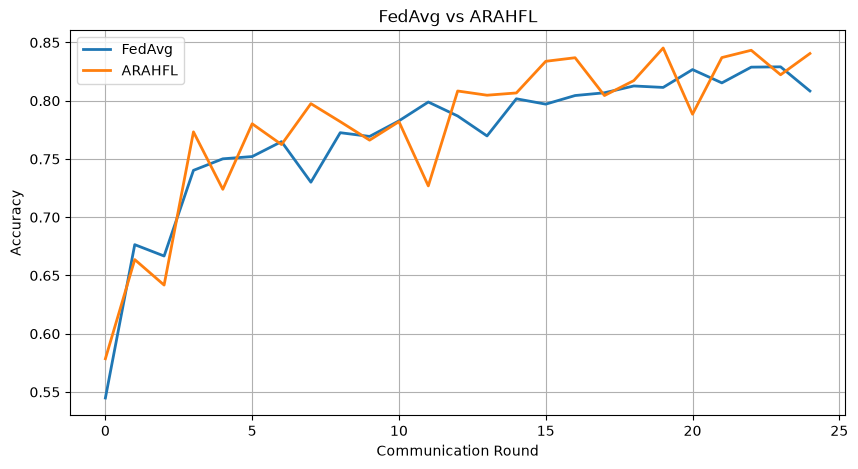

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    baseline_accuracy,
    label="FedAvg",
    linewidth=2
)

plt.plot(
    arahfl_accuracy,
    label="ARAHFL",
    linewidth=2
)

plt.xlabel("Communication Round")
plt.ylabel("Accuracy")
plt.title("FedAvg vs ARAHFL")

plt.legend()
plt.grid(True)

plt.show()

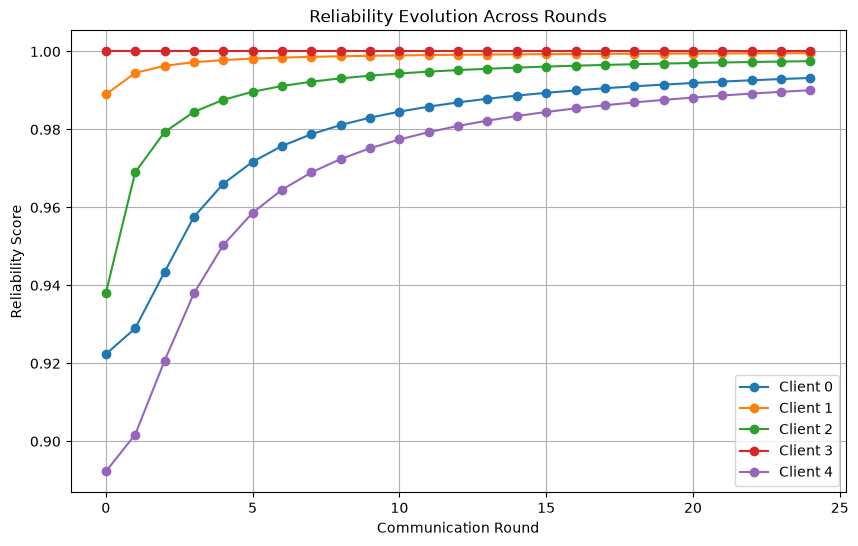

In [18]:
import matplotlib.pyplot as plt
import numpy as np

reliability_history = np.array(
    server.get_reliability_history()
)

plt.figure(figsize=(10,6))

for client_id in range(
    reliability_history.shape[1]
):
    plt.plot(
        reliability_history[:, client_id],
        marker='o',
        label=f'Client {client_id}'
    )

plt.title(
    "Reliability Evolution Across Rounds"
)

plt.xlabel(
    "Communication Round"
)

plt.ylabel(
    "Reliability Score"
)

plt.grid(True)

plt.legend()

plt.show()

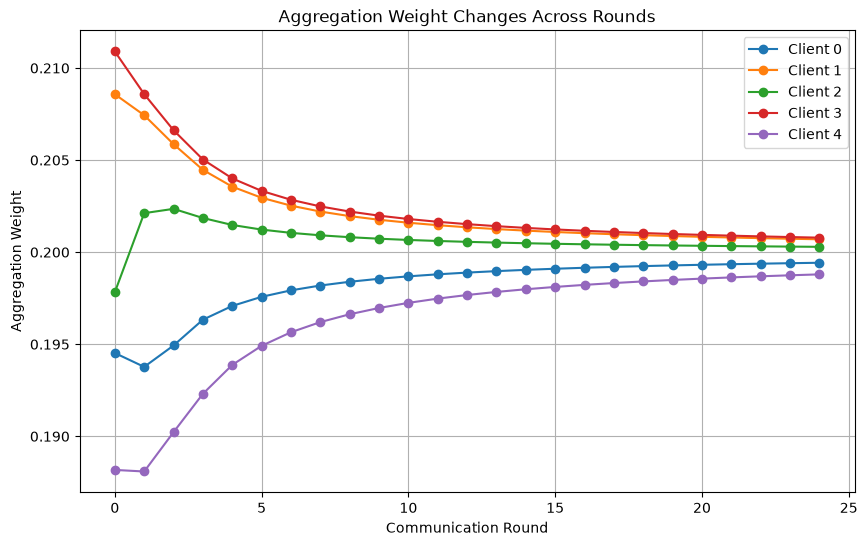

In [19]:
import matplotlib.pyplot as plt
import numpy as np

weight_history = np.array(
    server.get_weight_history()
)

plt.figure(figsize=(10,6))

for client_id in range(
    weight_history.shape[1]
):
    plt.plot(
        weight_history[:, client_id],
        marker='o',
        label=f'Client {client_id}'
    )

plt.title(
    "Aggregation Weight Changes Across Rounds"
)

plt.xlabel(
    "Communication Round"
)

plt.ylabel(
    "Aggregation Weight"
)

plt.grid(True)

plt.legend()

plt.show()